In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. IMPORT LIBRARIES
# =========================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (
    MobileNetV3Small,
    MobileNetV3Large,
    EfficientNetB0,
    ResNet50,
    DenseNet121
)
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# 3. PATH CONFIG
# =========================
BASE_PATH = "/content/drive/MyDrive/dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 10

# =========================
# 4. LOAD DATA
# =========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print("Classes:", class_names)

# =========================
# 5. DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# =========================
# 6. MODEL BUILDER
# =========================
def build_model(base_model_fn, name):
    base_model = base_model_fn(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = tf.keras.applications.imagenet_utils.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

# =========================
# 7. TRAIN + EVALUATE
# =========================
def train_and_evaluate(model_name, base_fn):
    print(f"\n===== Training {model_name} =====")

    model, base_model = build_model(base_fn, model_name)

    # Train classifier head
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD
    )

    # Fine tuning
    base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE
    )

    # =========================
    # TEST EVALUATION
    # =========================
    print(f"\n===== Testing {model_name} =====")

    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(classification_report(y_true, y_pred, target_names=class_names))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    loss, acc = model.evaluate(test_ds)
    print(f"{model_name} Test Accuracy: {acc:.4f}")

    return model_name, acc

# =========================
# 8. RUN ALL MODELS
# =========================
models_to_run = {
    "MobileNetV3Small": MobileNetV3Small,
    "MobileNetV3Large": MobileNetV3Large,
    "EfficientNetB0": EfficientNetB0,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121
}

results = []

for name, fn in models_to_run.items():
    model_name, acc = train_and_evaluate(name, fn)
    results.append((model_name, acc))

# =========================
# 9. FINAL COMPARISON
# =========================
print("\n===== FINAL RESULTS =====")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

Mounted at /content/drive
Found 1039 files belonging to 2 classes.
Found 130 files belonging to 2 classes.
Found 131 files belonging to 2 classes.
Classes: ['fake', 'real']

===== Training MobileNetV3Small =====
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 139s 768ms/step - accuracy: 0.7267 - loss: 0.6339 - val_accuracy: 0.7538 - val_loss: 0.4724
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8441 - loss: 0.4153 - val_accuracy: 0.7538 - val_loss: 0.4480
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8662 - loss: 0.3174 - val_accuracy: 0.8077 - val_loss: 0.3912
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9028 - loss: 0.2659 - val_accuracy: 0.7846 - val_loss: 0.4452
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9143 - loss: 0.2309 - val_accuracy: 0.7615 - val_loss: 0.5048
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9057 - loss: 0.2368 - val_accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

        fake       0.91      0.81      0.86        63
        real       0.84      0.93      0.88        68

    accuracy                           0.87       131
   macro avg       0.88      0.87      0.87       131
weighted avg       0.87      0.87      0.87       131

Confusion Matrix:
 [[51 12]
 [ 5 63]]
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8702 - loss: 0.3812 
EfficientNetB0 Test Accuracy: 0.8702

===== Training ResNet50 =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - accuracy: 0.7806 - loss: 0.6267 - val_accuracy: 0.7769 - val_loss: 0.4708
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.8778 - loss: 0.3337 - val_accuracy: 0.8385 - val_loss: 0.4201
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.8980 - loss: 0.2705 - val_accuracy: 0.8385 - val_loss: 0.3768
Epoch 4/10
33/33 ━━━━━

In [2]:
import pandas as pd

data = {
    "Model": ["MobileNetV3Small", "MobileNetV3Large", "EfficientNetB0", "ResNet50", "DenseNet121"],
    "Accuracy": [0.7939, 0.8092, 0.8702, 0.8931, 0.8550]
}

df = pd.DataFrame(data)
df

,Model,Accuracy
0,MobileNetV3Small,0.7939
1,MobileNetV3Large,0.8092
2,EfficientNetB0,0.8702
3,ResNet50,0.8931
4,DenseNet121,0.8550


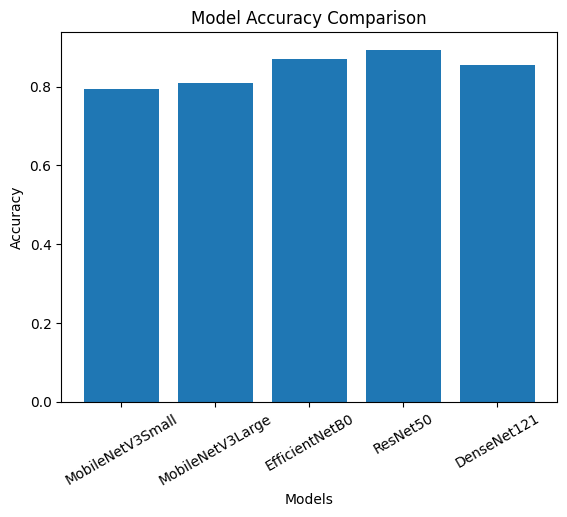

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()